1. developper differents modeles de ML: pour cela il faut tester different modele et retenir celui qui a le meilleur performance.
2. Essayer d'ameliorer la performance: En optimisation ses hyperparametres.
3. compromis de Precision/Recall: enfin de trouver le meilleur threshold 

procedure a suivre:
1. creons une liste de modele puis retenons celui qui a le plus grand score puis faire un peu de reglage sur le modele lui mm    

In [1]:
import matplotlib.pyplot as plt 
import numpy as np 
import pandas as pd 
import seaborn as sbn 
from mpl_toolkits.mplot3d import axes3d
#% matplotlib inline

In [2]:
datasetcovid=pd.read_excel('dataset.xlsx')

In [3]:
pd.set_option('display.max_row',111)

In [4]:
#une nouvelle copie du dataset original
data_preproccessing=datasetcovid.copy()

In [5]:
# la 1ere de chose c'est de selectionner les variables qu'on a juge utiles dans le EDA
missing_rate=data_preproccessing.isna().sum(axis=0)/data_preproccessing.shape[0]
#creons la liste des variables les plus importantes
blood_columns2=list(data_preproccessing.columns[(missing_rate<0.9) & (missing_rate>0.88)])
viral_columns2=list(data_preproccessing.columns[(missing_rate<0.80) & (missing_rate>0.75)])
key_columns=['Patient age quantile','SARS-Cov-2 exam result']

In [6]:
data_preproccessing=data_preproccessing[key_columns + blood_columns2 + viral_columns2]

In [7]:
pd.set_option('display.max_column',data_preproccessing.shape[1])#permet d'afficher  colonne
data_preproccessing.head(5)

,Patient age quantile,SARS-Cov-2 exam result,Hematocrit,Hemoglobin,Platelets,Mean platelet volume,Red blood Cells,Lymphocytes,Mean corpuscular hemoglobin concentration (MCHC),Leukocytes,Basophils,Mean corpuscular hemoglobin (MCH),Eosinophils,Mean corpuscular volume (MCV),Monocytes,Red blood cell distribution width (RDW),Respiratory Syncytial Virus,Influenza A,Influenza B,Parainfluenza 1,CoronavirusNL63,Rhinovirus/Enterovirus,Coronavirus HKU1,Parainfluenza 3,Chlamydophila pneumoniae,Adenovirus,Parainfluenza 4,Coronavirus229E,CoronavirusOC43,Inf A H1N1 2009,Bordetella pertussis,Metapneumovirus,Parainfluenza 2
0,13,negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,17,negative,0.236515,-0.02234,-0.517413,0.010677,0.102004,0.318366,-0.95079,-0.09461,-0.223767,-0.292269,1.482158,0.166192,0.357547,-0.625073,not_detected,not_detected,not_detected,not_detected,not_detected,detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected
2,8,negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5,negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,15,negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_detected,not_detected,not_detected,not_detected,not_detected,detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected


In [8]:
#import train_test_split depuis le module model selection.
from sklearn.model_selection import train_test_split
trainset,testset= train_test_split(data_preproccessing,test_size=0.2,random_state=45)
testset.head(3)

,Patient age quantile,SARS-Cov-2 exam result,Hematocrit,Hemoglobin,Platelets,Mean platelet volume,Red blood Cells,Lymphocytes,Mean corpuscular hemoglobin concentration (MCHC),Leukocytes,Basophils,Mean corpuscular hemoglobin (MCH),Eosinophils,Mean corpuscular volume (MCV),Monocytes,Red blood cell distribution width (RDW),Respiratory Syncytial Virus,Influenza A,Influenza B,Parainfluenza 1,CoronavirusNL63,Rhinovirus/Enterovirus,Coronavirus HKU1,Parainfluenza 3,Chlamydophila pneumoniae,Adenovirus,Parainfluenza 4,Coronavirus229E,CoronavirusOC43,Inf A H1N1 2009,Bordetella pertussis,Metapneumovirus,Parainfluenza 2
138,16,negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
433,11,negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1442,4,positive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
trainset.iloc[:,1].value_counts(),testset.iloc[:,1].value_counts()
#le proportion de chaque cas et bien respectee apres le decoupage

(SARS-Cov-2 exam result
 negative    4079
 positive     436
 Name: count, dtype: int64,
 SARS-Cov-2 exam result
 negative    1007
 positive     122
 Name: count, dtype: int64)

In [10]:
trainset.dropna().shape

(284, 33)

In [11]:
testset.dropna().shape

(78, 33)

In [12]:
trainset.shape

(4515, 33)

In [13]:
 #creons une fonction qui permet de faire l'encodage sur le train et le test
def encodage(data_preproccessing):
    #remplacons nos variables qualitalives par les varables quantitatives
    code={'positive':1,'negative':0,'detected':1,'not_detected':0}
    for col in data_preproccessing.select_dtypes('object'):
        data_preproccessing[col]=data_preproccessing[col].map(code)
    return data_preproccessing

In [14]:
encodage(trainset).dtypes.value_counts()

float64    31
int64       2
Name: count, dtype: int64

In [15]:
encodage(trainset)['Coronavirus229E'].value_counts()

Coronavirus229E
0.0    1078
1.0       5
Name: count, dtype: int64

In [16]:
def feature_engineering(dataframe):
    dataframe['est malade'] = dataframe[viral_columns2].sum(axis=1)>=1
    #eluminons toute les autres varables virarl
    dataframe=dataframe[key_columns + blood_columns2 + ['est malade']]

    return dataframe

In [17]:
# imputation
def imputation(dataframe):
    dataframe=encodage(dataframe)
    #ataframe.fillna(-999)
    #dataframe['']
    
    return dataframe.dropna(axis=0)


In [18]:
imputation(trainset).dtypes.value_counts()

float64    31
int64       2
Name: count, dtype: int64

In [19]:
def preprocessing(dataframe):
    dataframe=encodage(dataframe)
    #dataframe=feature_engineering(dataframe)
    dataframe=imputation(dataframe)
    print(dataframe.dtypes.value_counts(),type(dataframe))
    x=dataframe.drop(columns='SARS-Cov-2 exam result')
    y=dataframe['SARS-Cov-2 exam result']
    print('la proportion cas apres le preprocessing est de: {} {}'.format(x.shape,y.shape),sep="/n")
    return x,y

x_train,y_train=preprocessing(trainset)

float64    31
int64       2
Name: count, dtype: int64 <class 'pandas.core.frame.DataFrame'>
la proportion cas apres le preprocessing est de: (284, 32) (284,)


In [20]:
x_test,y_test=preprocessing(trainset)

float64    31
int64       2
Name: count, dtype: int64 <class 'pandas.core.frame.DataFrame'>
la proportion cas apres le preprocessing est de: (284, 32) (284,)


In [21]:
imputation(trainset).shape

(284, 33)

In [22]:
x_train.dtypes.value_counts()

float64    31
int64       1
Name: count, dtype: int64

In [23]:
for i in x_train.select_dtypes('int64'):
    print(i)

Patient age quantile


In [24]:
x_train.select_dtypes('int64')

,Patient age quantile
4484,4
5329,17
3432,4
4941,14
482,4
...,...
232,14
5230,13
196,18
4111,10


# Modelisation

   ### importons les defferents modeles de ML

In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier
from sklearn.svm import SVC #svm est tres efficace pour le dataset petit ou intermediare 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, confusion_matrix,classification_report
from sklearn.model_selection import learning_curve#permet de voir si notre modele est en over ou endre fitting
from sklearn.feature_selection import SelectKBest,f_classif #c'est le test d'anova
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import SGDClassifier

In [26]:
AdaBoostClassifier()

AdaBoostClassifier()

In [27]:
#un preprocessor qui permet de faire qulques operations
#preprocessor=make_pipeline(PolynomialFeatures(2,include_bias=False),
#                           SelectKBest(f_classif,k=10))
preprocessor=make_pipeline(PolynomialFeatures(2,include_bias=False))
#include_bias=False-permet d'enlever le colonne de biais 

In [28]:
# un liste de nos differents models sous forme d'un pipeline
DecisionTreeClassifier=make_pipeline(preprocessor,
                                     DecisionTreeClassifier(random_state=0))
RandomForestClassifier=make_pipeline(preprocessor,
                                     RandomForestClassifier(random_state=0))
AdaBoostClassifier=make_pipeline(preprocessor,
                                     AdaBoostClassifier(random_state=0))

#normalisons nos donnes avant d'utiliser un modele de kn_NEIGHBORS
from sklearn.preprocessing import MinMaxScaler,RobustScaler,StandardScaler
liste=[MinMaxScaler(),StandardScaler(),RobustScaler()]
KNeighborsClassifier=make_pipeline(preprocessor,liste[1],
                                     KNeighborsClassifier())
SVC=make_pipeline(preprocessor,liste[1],
                  SVC())

#les modeles bases sur les arbre de decision n'ont pas besoin des donnees normaliser

In [29]:
#Une liste de different modele de machine Learning
List_of_models={'DecisionTreeClassifier':DecisionTreeClassifier,
                'RandomForestClassifier':RandomForestClassifier,
               'AdaBoostClassifier':AdaBoostClassifier,
                'SVC':SVC,
                'KNeighborsClassifier':KNeighborsClassifier}

In [30]:
def evaluation(model):
    model.fit(x_train,y_train)
    score=model.score(x_train,y_train)
    y_prediction=model.predict(x_test)
    matrice_de_confusion=confusion_matrix(y_test,y_prediction)
    report=classification_report(y_test,y_prediction)
    print('la matrice de confusion \n {}'.format(matrice_de_confusion))
    print('{}'.format(report))
    
    #Essayons d'ameliorer le modele en tracant la courbe de validation enfin de bien comprendre notre modele.
    N,train_score,test_score=learning_curve(model,
                                            x_train,y_train,
                                           cv=4, scoring='f1',train_sizes=np.linspace(0.1,1,10))
    #tracons ls courbes
    plt.figure()
    
    plt.plot(N, train_score.mean(axis=1),color='b',label='le score sur le train')
    plt.plot(N, test_score.mean(axis=1),color='red',label='le score sur la validation ')
    #plt.title(nom_model)
    plt.legend()

le resultat du modele DecisionTreeClassifier:
la matrice de confusion 
 [[242   0]
 [  0  42]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       242
           1       1.00      1.00      1.00        42

    accuracy                           1.00       284
   macro avg       1.00      1.00      1.00       284
weighted avg       1.00      1.00      1.00       284

le resultat du modele RandomForestClassifier:
la matrice de confusion 
 [[242   0]
 [  0  42]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       242
           1       1.00      1.00      1.00        42

    accuracy                           1.00       284
   macro avg       1.00      1.00      1.00       284
weighted avg       1.00      1.00      1.00       284

le resultat du modele AdaBoostClassifier:


C:\Users\User\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


la matrice de confusion 
 [[242   0]
 [  0  42]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       242
           1       1.00      1.00      1.00        42

    accuracy                           1.00       284
   macro avg       1.00      1.00      1.00       284
weighted avg       1.00      1.00      1.00       284



C:\Users\User\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\User\an

le resultat du modele SVC:
la matrice de confusion 
 [[242   0]
 [ 26  16]]
              precision    recall  f1-score   support

           0       0.90      1.00      0.95       242
           1       1.00      0.38      0.55        42

    accuracy                           0.91       284
   macro avg       0.95      0.69      0.75       284
weighted avg       0.92      0.91      0.89       284

le resultat du modele KNeighborsClassifier:
la matrice de confusion 
 [[233   9]
 [ 16  26]]
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       242
           1       0.74      0.62      0.68        42

    accuracy                           0.91       284
   macro avg       0.84      0.79      0.81       284
weighted avg       0.91      0.91      0.91       284



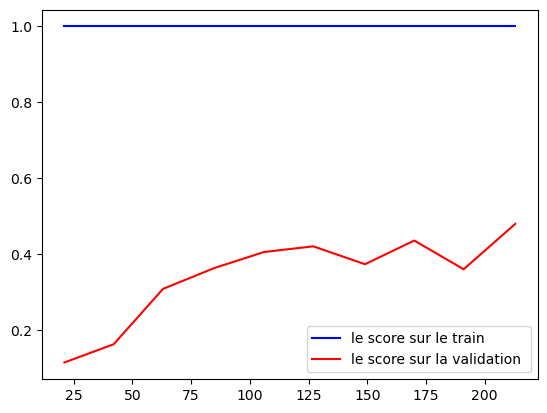

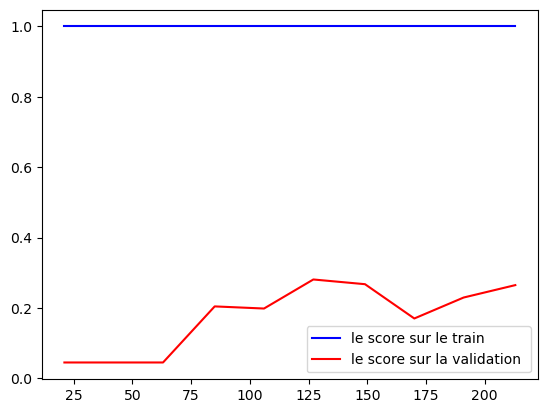

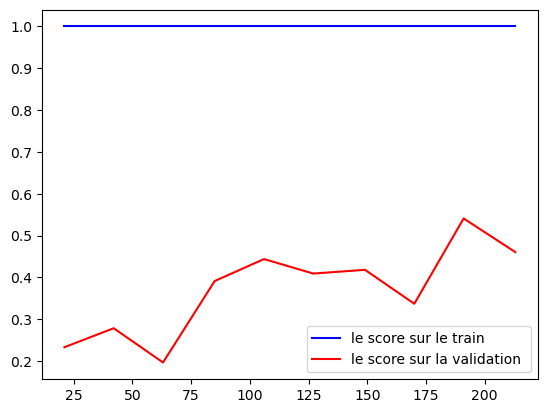

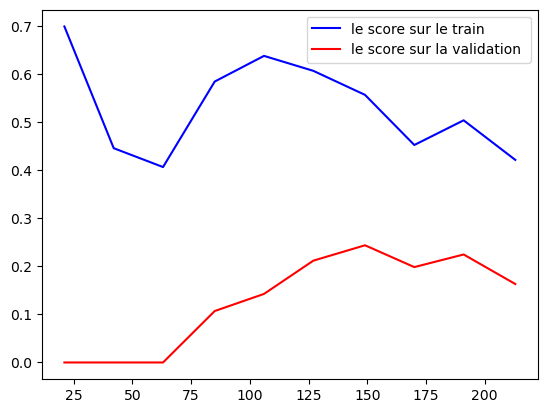

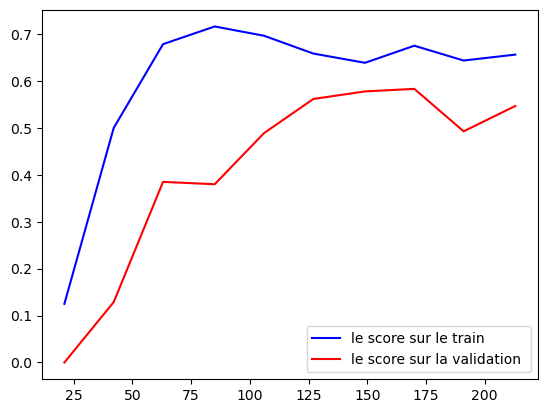

In [31]:
for modele,value in List_of_models.items():
    print('le resultat du modele {}:'.format(modele))
    evaluation(value)

selon le resultat des differents graphique on peut remarquer que le 1er modele est en overfitting car la machine n'arrive pas a generalise,on remarque aussi que le 3eme modele est mieux que le deux precedant car le score du validation monte plus vite. En por les deux derniers on voit qlqchose de tres interressante: bien que le score du train diminue, il ya un rapprochement entre le train et le validation score et c'est un tres bon signe car le modele generalise plus vite.

### Optimisation d'un modele.
c.a.d essayer de trouver les meilleurs hyperparametre. dans notre cas Adaboost

In [32]:
#permet de voir les differents parametre du model 
SVC.get_params()

{'memory': None,
 'steps': [('pipeline',
   Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(include_bias=False))])),
  ('standardscaler', StandardScaler()),
  ('svc', SVC())],
 'verbose': False,
 'pipeline': Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(include_bias=False))]),
 'standardscaler': StandardScaler(),
 'svc': SVC(),
 'pipeline__memory': None,
 'pipeline__steps': [('polynomialfeatures',
   PolynomialFeatures(include_bias=False))],
 'pipeline__verbose': False,
 'pipeline__polynomialfeatures': PolynomialFeatures(include_bias=False),
 'pipeline__polynomialfeatures__degree': 2,
 'pipeline__polynomialfeatures__include_bias': False,
 'pipeline__polynomialfeatures__interaction_only': False,
 'pipeline__polynomialfeatures__order': 'C',
 'standardscaler__copy': True,
 'standardscaler__with_mean': True,
 'standardscaler__with_std': True,
 'svc__C': 1.0,
 'svc__break_ties': False,
 'svc__cache_size': 200,
 'svc__class_weight': None,
 'svc__coef0': 0.0,
 'svc__deci

les hyperparamtre le plus important pour SVM c'est le le coeff de penalite et le gamma.

In [33]:
# importons grigsearcheCV
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV

"""
gridparams={'svc__gamma': [1e-3,1e-4,1e-2],
    'svc__C':[1,10,100,1000]       
}

"""
RandomizedSearchCV_params={'svc__gamma': [1e-3,1e-4,1e-2],
                           'svc__C':[1,10,100,1000],
                           'pipeline__polynomialfeatures__degree':[2,3,4]#,'pipeline__selectkbest__k':np.arange(40,60)  
                          }

#grid=GridSearchCV(SVC,gridparams,scoring='recall',cv=4)

Randomgrid=RandomizedSearchCV(SVC,RandomizedSearchCV_params,scoring='recall',cv=4,n_iter=40)
#n_iter c'est le nombre diteration cad le nombre de combunaison differente enfin de trouver les meilleurs hyperparametre
Randomgrid.fit(x_train,y_train)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 36 is smaller than n_iter=40. Running 36 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


RandomizedSearchCV(cv=4,
                   estimator=Pipeline(steps=[('pipeline',
                                              Pipeline(steps=[('polynomialfeatures',
                                                               PolynomialFeatures(include_bias=False))])),
                                             ('standardscaler',
                                              StandardScaler()),
                                             ('svc', SVC())]),
                   n_iter=40,
                   param_distributions={'pipeline__polynomialfeatures__degree': [2,
                                                                                 3,
                                                                                 4],
                                        'svc__C': [1, 10, 100, 1000],
                                        'svc__gamma': [0.001, 0.0001, 0.01]},
                   scoring='recall')

In [34]:
Randomgrid.best_params_

{'svc__gamma': 0.001,
 'svc__C': 1000,
 'pipeline__polynomialfeatures__degree': 2}

In [35]:
Randomgrid.best_score_

0.7136363636363636

In [36]:
meilleur_stimateur=Randomgrid.best_estimator_ #le meilleur stimateur

In [37]:
y_pred=meilleur_stimateur.predict(x_test)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[242   0]
 [  0  42]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       242
           1       1.00      1.00      1.00        42

    accuracy                           1.00       284
   macro avg       1.00      1.00      1.00       284
weighted avg       1.00      1.00      1.00       284



la matrice de confusion 
 [[242   0]
 [  0  42]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       242
           1       1.00      1.00      1.00        42

    accuracy                           1.00       284
   macro avg       1.00      1.00      1.00       284
weighted avg       1.00      1.00      1.00       284



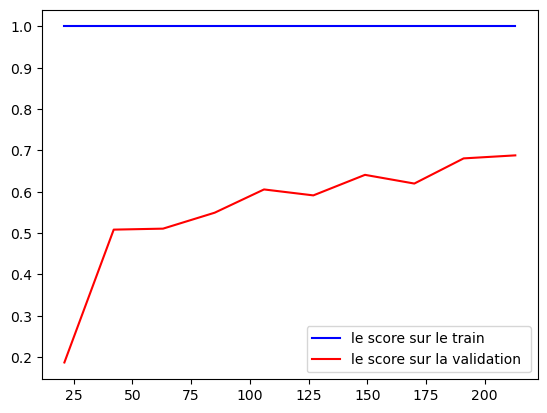

In [38]:
evaluation(meilleur_stimateur)

on pourra encore essayer d'optimiser tout les hyper parametre en fin d'obtenir un meilleur resultst avec gridsearchCV. mais faire un si grand recherche a grid a un cout, le tps. pour paliera ce probleme l'alternative est d'utiliser un RandomSearchCV qui cherche de facon aleatoire differente combunaison dans tt le domaine de hyperp.

finalisons la creation du modele en observant les courbe precisions/recalls et en definisant un seil de prediction(decision banderie pour notre modele.

## Precision Recall curve.

In [39]:
from sklearn.metrics import precision_recall_curve

c'est une fonction qui ns permet de vusialiser la future precision(sensibilite) du modele en fonction d'un seil de prediction que nous allons definir .en effet la plus part des modele ont une fonction de Decison qui nous permet de calcuer la probabilite p(x) qui ns permet de faire en suite une prediction. par ex si p<notre_seil alors negative, au cas contraire positive.

In [40]:
prediction,recall,threshold=precision_recall_curve(y_test,meilleur_stimateur.decision_function(x_test))

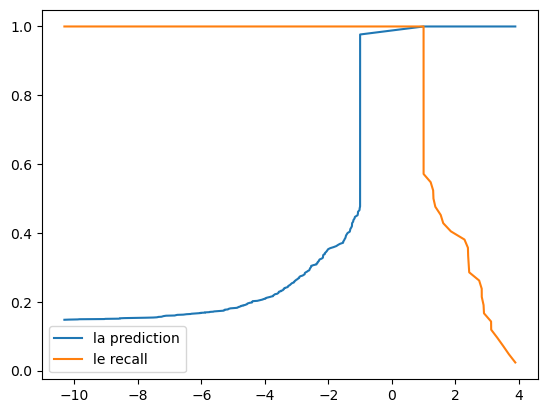

In [41]:
#affichons le trois tableaux 
plt.plot(threshold,prediction[:-1],label='la prediction')
plt.plot(threshold,recall[:-1],label='le recall')
plt.legend()

la precision permet de reduir au maximum les faux positive. par ex un precision de 100% signifit qu'aucune personne negative n'a ete par erreur classee coe positive. le recall c'est inverse. un bon modele c'est quand le recall et pa recision tendent vers le 100%. Idee est de trouve le meilleur threshold qui ns permet de trouver le meilleur precision et recall, de maniere generale c'est la ou les deux coube se croisent(score f1). Mais pour atteindre notre objectif de depart on peut sacrifier un peu de precision pour trour un bon recall. par ex thresold=-0.5

In [42]:
True + 1

2

## Evlautaion final

In [43]:
def model_final(modele,x,threshold):
    return modele.decision_function(x) >threshold

In [57]:
nouveau_y_pred=model_final(meilleur_stimateur,x_test,threshold=-0.85)

#evalution avec le score f1
from sklearn.metrics import precision_score,f1_score,recall_score
print('on a un score f1 de: {}' .format(f1_score(y_test,nouveau_y_pred)))
print('on a un recall de: {}' .format(recall_score(y_test,nouveau_y_pred)))

on a un score f1 de: 1.0
on a un recall de: 1.0


In [58]:
x_test.shape[0],meilleur_stimateur.decision_function(x_test).size

(284, 284)

In [59]:
import numpy as np
import pandas as pd
from scipy import stats

# Génération de données de test simulées
np.random.seed(123)
group1 = np.random.normal(10, 2, 100)
group2 = np.random.normal(12, 2, 100)
group3 = np.random.normal(14, 2, 100)

# Stockage des données dans un dataframe
data = np.concatenate([group1, group2, group3])
groups = ["group1"] * 100 + ["group2"] * 100 + ["group3"] * 100
df = pd.DataFrame({"data": data, "group": groups})
df

,data,group
0,7.828739,group1
1,11.994691,group1
2,10.565957,group1
3,6.987411,group1
4,8.842799,group1
...,...,...
295,15.391575,group3
296,17.751601,group3
297,14.831389,group3
298,14.321089,group3


In [60]:
# Exécution de l'ANOVA
f_value, p_value = stats.f_oneway(df[df['group'] == "group1"]['data'],
                                  df[df['group'] == "group2"]['data'],
                                  df[df['group'] == "group3"]['data'])

print("F-value: ", f_value)
print("P-value: ", p_value)

# Interprétation des résultats
if p_value < 0.05:
    print("Les moyennes des groupes sont significativement différentes.")
else:
    print("Les moyennes des groupes ne sont pas significativement différentes.")


F-value:  83.01949006047968
P-value:  2.2915330324233117e-29
Les moyennes des groupes sont significativement différentes.


In [65]:
data1 = np.concatenate([group1, group1, group1])
df = pd.DataFrame({"data": data1, "group": groups})
# Exécution de l'ANOVA
f_value, p_value = stats.f_oneway(df[df['group'] == "group1"]['data'],
                                  df[df['group'] == "group2"]['data'],
                                  df[df['group'] == "group3"]['data'])

print("F-value: ", f_value)
print("P-value: ", p_value)

# Interprétation des résultats
if p_value < 0.05:
    print("Les moyennes des groupes sont significativement différentes.")
else:
    print("Les moyennes des groupes ne sont pas significativement différentes.")

F-value:  -1.3804313011196513e-31
P-value:  nan
Les moyennes des groupes ne sont pas significativement différentes.


In [61]:
prediction.size,prediction[:-1].size

(285, 284)

In [62]:
threshold.size,threshold.min(),threshold.max()

(284, -10.315677324096065, 3.8892876983307234)

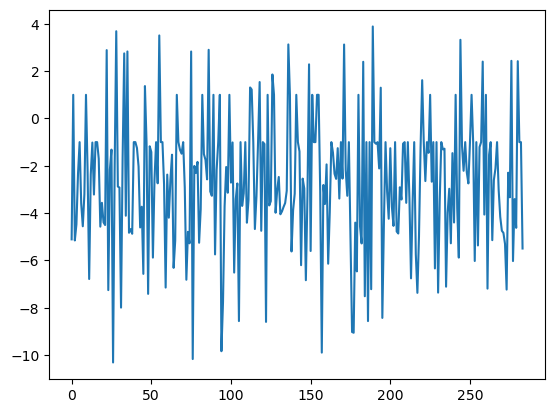

In [63]:
plt.plot(meilleur_stimateur.decision_function(x_test))

In [64]:
datasetcovid[(datasetcovid.isna()==True).sum(axis=1)==0]

,Patient ID,Patient age quantile,SARS-Cov-2 exam result,"Patient addmited to regular ward (1=yes, 0=no)","Patient addmited to semi-intensive unit (1=yes, 0=no)","Patient addmited to intensive care unit (1=yes, 0=no)",Hematocrit,Hemoglobin,Platelets,Mean platelet volume,Red blood Cells,Lymphocytes,Mean corpuscular hemoglobin concentration (MCHC),Leukocytes,Basophils,Mean corpuscular hemoglobin (MCH),...,Creatine phosphokinase (CPK),Ferritin,Arterial Lactic Acid,Lipase dosage,D-Dimer,Albumin,Hb saturation (arterial blood gases),pCO2 (arterial blood gas analysis),Base excess (arterial blood gas analysis),pH (arterial blood gas analysis),Total CO2 (arterial blood gas analysis),HCO3 (arterial blood gas analysis),pO2 (arterial blood gas analysis),Arteiral Fio2,Phosphor,ctO2 (arterial blood gas analysis)


In [52]:
datasetcovid

,Patient ID,Patient age quantile,SARS-Cov-2 exam result,"Patient addmited to regular ward (1=yes, 0=no)","Patient addmited to semi-intensive unit (1=yes, 0=no)","Patient addmited to intensive care unit (1=yes, 0=no)",Hematocrit,Hemoglobin,Platelets,Mean platelet volume,Red blood Cells,Lymphocytes,Mean corpuscular hemoglobin concentration (MCHC),Leukocytes,Basophils,Mean corpuscular hemoglobin (MCH),...,Creatine phosphokinase (CPK),Ferritin,Arterial Lactic Acid,Lipase dosage,D-Dimer,Albumin,Hb saturation (arterial blood gases),pCO2 (arterial blood gas analysis),Base excess (arterial blood gas analysis),pH (arterial blood gas analysis),Total CO2 (arterial blood gas analysis),HCO3 (arterial blood gas analysis),pO2 (arterial blood gas analysis),Arteiral Fio2,Phosphor,ctO2 (arterial blood gas analysis)
0,44477f75e8169d2,13,negative,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,126e9dd13932f68,17,negative,0,0,0,0.236515,-0.022340,-0.517413,0.010677,0.102004,0.318366,-0.950790,-0.094610,-0.223767,-0.292269,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,a46b4402a0e5696,8,negative,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,f7d619a94f97c45,5,negative,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,d9e41465789c2b5,15,negative,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5639,ae66feb9e4dc3a0,3,positive,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5640,517c2834024f3ea,17,negative,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5641,5c57d6037fe266d,4,negative,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5642,c20c44766f28291,10,negative,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
from sklearn.impute import SimpleImputer
SimpleImputer.fit_transform(datasetcovid[blood_columns2].array)

AttributeError: 'DataFrame' object has no attribute 'array'

In [ ]:
datasetcovid[blood_columns2]

In [ ]:
data_preproccessing.dropna()

In [ ]:
testset.dropna()

In [ ]:
import itertools 

In [ ]:
len(list(itertools.product([1,2,3],[4,5,6],(7,8,9,10))))